# End-to-End Customer Churn Prediction — MLOps Project

This project demonstrates the complete machine learning lifecycle:
data preprocessing, model training, experiment tracking,
model deployment, containerization, CI/CD and cloud deployment.

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow fastapi uvicorn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [14]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [15]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [16]:
df["TotalCharges"].dtype

dtype('O')

In [17]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
df = df.dropna(subset=["TotalCharges"])

In [20]:
df.shape

(7032, 21)

In [21]:
df = df.drop(columns=["customerID"])

In [22]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


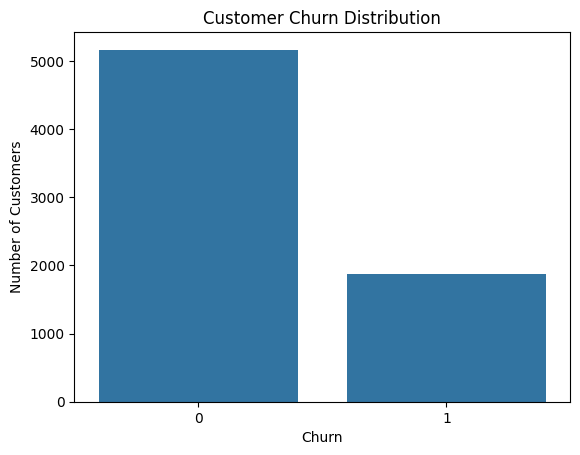

In [23]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

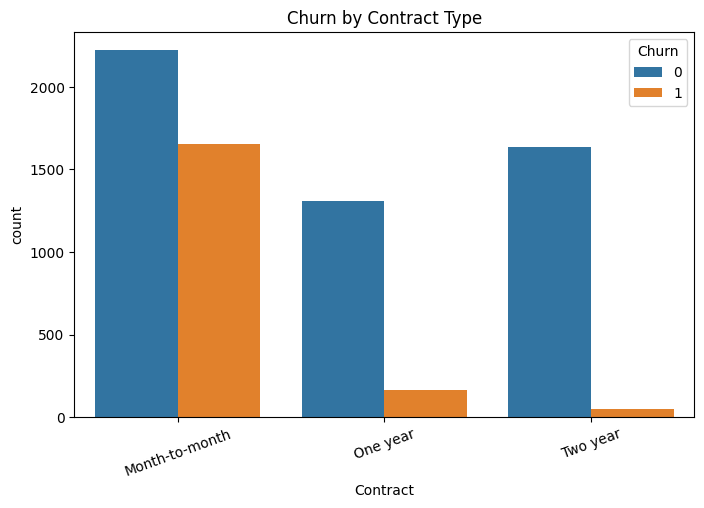

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn by Contract Type")
plt.xticks(rotation=20)

plt.show()

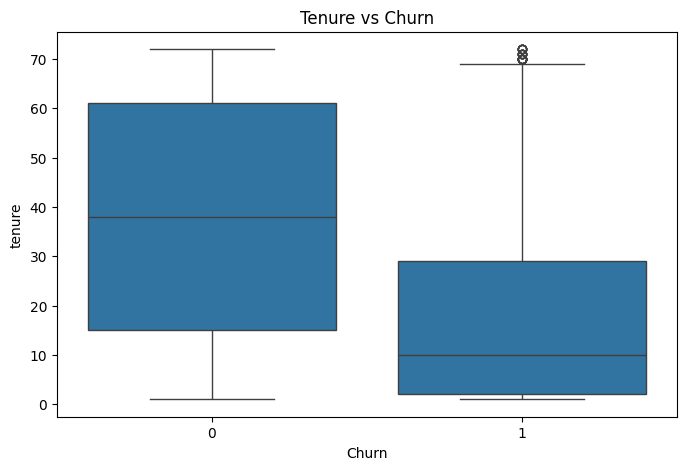

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

In [26]:
y = df["Churn"]

In [27]:
X = df.drop(columns=["Churn"])

In [28]:
X.shape

(7032, 19)

In [29]:
y.shape

(7032,)

In [30]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5625, 19)
Testing: (1407, 19)


In [33]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [34]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [35]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [36]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [37]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [38]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [39]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [40]:
logistic_metrics = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test
)

Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1 Score : 0.608
ROC-AUC  : 0.8359


In [41]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

In [42]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))])

In [43]:
rf_metrics = evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)

Accuracy : 0.791
Precision: 0.6307
Recall   : 0.516
F1 Score : 0.5676
ROC-AUC  : 0.8302


In [44]:
results = pd.DataFrame([
    logistic_metrics,
    rf_metrics
], index=[
    "Logistic Regression",
    "Random Forest"
])

results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
Random Forest,0.791045,0.630719,0.516043,0.567647,0.830180


In [45]:
best_model = logistic_pipeline

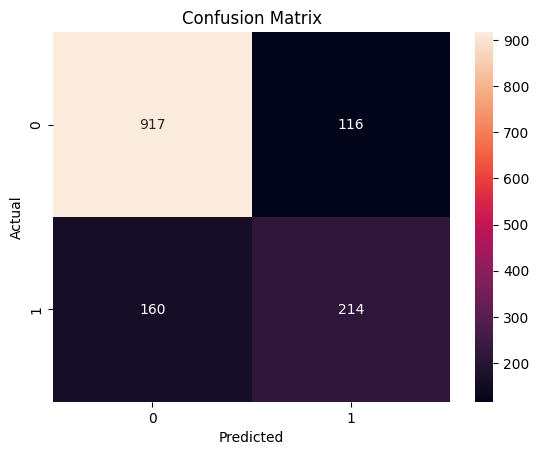

In [46]:
predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

MLops


In [47]:
!pip install -q mlflow

In [48]:
import mlflow
import mlflow.sklearn

In [49]:
mlflow.set_experiment("Customer_Churn_Prediction")

2026/10/07 09:45:42 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/07 09:45:42 INFO mlflow.store.db.utils: Updating database tables
2026/10/07 09:45:52 INFO mlflow.tracking.fluent: Experiment with name 'Customer_Churn_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1791366352798, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791366352798, lifecycle_stage='active', name='Customer_Churn_Prediction', tags={}, trace_location=None, workspace='default'>

In [51]:
with mlflow.start_run():

    model = LogisticRegression(max_iter=1000)

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(
    pipeline,
    name="model",
    skops_trusted_types=[
        "numpy.dtype",
        "sklearn.compose._column_transformer._RemainderColsList"
    ]
)

    print("Model logged successfully.")

Model logged successfully.


In [52]:
import joblib

joblib.dump(
    best_model,
    "customer_churn_model.pkl"
)

['customer_churn_model.pkl']

In [53]:
!ls -lh

total 1.9M
-rw-r--r-- 1 root root 8.4K Oct  7 09:51 customer_churn_model.pkl
-rw-r--r-- 1 root root 932K Oct  7 09:50 mlflow.db
drwxr-xr-x 3 root root 4.0K Oct  7 09:50 mlruns
drwxr-xr-x 1 root root 4.0K Oct  2 13:50 sample_data
-rw-r--r-- 1 root root 948K Oct  7 09:35 Telco-Customer-Churn.csv


In [54]:
from google.colab import files

files.download("customer_churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
!pip install -q joblib

In [56]:
import joblib

joblib.dump(
    pipeline,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [57]:
loaded_model = joblib.load("customer_churn_model.pkl")

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [58]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)[:, 1]

print("Prediction:", prediction[0])
print("Churn probability:", probability[0])

Prediction: 0
Churn probability: 0.017513027676191607


In [59]:
!pip install -q fastapi uvicorn

In [60]:
%%writefile main.py

from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI(
    title="Customer Churn Prediction API",
    description="ML API for predicting customer churn",
    version="1.0"
)

model = joblib.load("customer_churn_model.pkl")


@app.get("/")
def home():
    return {
        "message": "Customer Churn Prediction API",
        "status": "running"
}


@app.post("/predict")
def predict(data: dict):

    input_data = pd.DataFrame([data])

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    return {
        "churn_prediction": int(prediction),
        "churn_probability": float(probability)
    }

Writing main.py


In [61]:
!uvicorn main:app --host 0.0.0.0 --port 8000 &

INFO:     Started server process [6711]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [6711]


In [62]:
print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [63]:
print("Prediction:", prediction[0])
print("Churn probability:", probability[0])

Prediction: 0
Churn probability: 0.017513027676191607


In [64]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [65]:
%%writefile main.py

from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd


# --------------------------------------------------
# Create FastAPI application
# --------------------------------------------------

app = FastAPI(
    title="Customer Churn Prediction API",
    description="Machine Learning API for predicting customer churn",
    version="1.0.0"
)


# --------------------------------------------------
# Load trained ML pipeline
# --------------------------------------------------

model = joblib.load("customer_churn_model.pkl")


# --------------------------------------------------
# Input schema
# --------------------------------------------------

class Customer(BaseModel):

    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float


# --------------------------------------------------
# Home endpoint
# --------------------------------------------------

@app.get("/")
def home():

    return {
        "message": "Customer Churn Prediction API",
        "status": "running",
        "version": "1.0.0"
    }


# --------------------------------------------------
# Prediction endpoint
# --------------------------------------------------

@app.post("/predict")
def predict(customer: Customer):

    # Convert Pydantic object to dictionary
    customer_data = customer.model_dump()

    # Convert dictionary to DataFrame
    input_data = pd.DataFrame([customer_data])

    # Make prediction
    prediction = model.predict(input_data)[0]

    # Get probability
    probability = model.predict_proba(input_data)[0][1]

    # Convert prediction to readable result
    churn_result = "Yes" if prediction == 1 else "No"

    return {
        "churn_prediction": int(prediction),
        "churn": churn_result,
        "churn_probability": round(float(probability), 4)
    }

Overwriting main.py


In [66]:
!pkill -f uvicorn

In [67]:
!uvicorn main:app --host 0.0.0.0 --port 8000 &

INFO:     Started server process [8508]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [8508]


In [69]:
!nohup uvicorn main:app --host 0.0.0.0 --port 8000 > uvicorn.log 2>&1 &

In [70]:
!cat uvicorn.log

INFO:     Started server process [8885]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [71]:
import requests

sample_customer = X_test.iloc[0].to_dict()

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=sample_customer
)

print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'churn_prediction': 0, 'churn': 'No', 'churn_probability': 0.0175}


In [72]:
bad_customer = sample_customer.copy()

bad_customer["tenure"] = "hello"

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=bad_customer
)

print("Status code:", response.status_code)
print(response.json())

Status code: 422
{'detail': [{'type': 'int_parsing', 'loc': ['body', 'tenure'], 'msg': 'Input should be a valid integer, unable to parse string as an integer', 'input': 'hello'}]}


In [73]:
incomplete_customer = sample_customer.copy()

del incomplete_customer["tenure"]

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=incomplete_customer
)

print("Status code:", response.status_code)
print(response.json())

Status code: 422
{'detail': [{'type': 'missing', 'loc': ['body', 'tenure'], 'msg': 'Field required', 'input': {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Two year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Credit card (automatic)', 'MonthlyCharges': 75.95, 'TotalCharges': 4542.35}}]}


In [74]:
customer = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 24,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "No",
    "DeviceProtection": "Yes",
    "TechSupport": "Yes",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "MonthlyCharges": 65.5,
    "TotalCharges": 1572.0
}

In [75]:
response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=customer
)

print(response.status_code)
print(response.json())

200
{'churn_prediction': 0, 'churn': 'No', 'churn_probability': 0.0568}


In [76]:
%%writefile requirements.txt

fastapi
uvicorn
pandas
numpy
scikit-learn
joblib
pydantic

Writing requirements.txt


In [77]:
!cat requirements.txt


fastapi
uvicorn
pandas
numpy
scikit-learn
joblib
pydantic


In [78]:
%%writefile Dockerfile

FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY main.py .
COPY customer_churn_model.pkl .

EXPOSE 8000

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


In [79]:
from google.colab import files

files.download("main.py")
files.download("customer_churn_model.pkl")
files.download("requirements.txt")
files.download("Dockerfile")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>